In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic
from astropy import constants as c

In [2]:
from specs import *
from classy_wraper_for_m21cm import *

In [3]:
from meer21cm import util
from meer21cm.plot import plot_map
from meer21cm import PowerSpectrum
from meer21cm.power import get_modelpk_conv

In [4]:
import niceplots
niceplots.initPlot()

In [5]:
ps = PowerSpectrum(
    wproj=wcs,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
    nu=nu_arr,
    ra_range=ra_range,
    dec_range=dec_range,
    # downscale the resolution along line-of-sight
    downres_factor_radial = 1.5,
    # downscale the resolution on the transverse plane
    downres_factor_transverse = 1.2,
    omega_hi = 5e-4,
    tracer_bias_1 = 1.5,
    mean_amp_1 = 'average_hi_temp'
)

array([ 734.32853136, 2405.926011  ,  830.18114564])

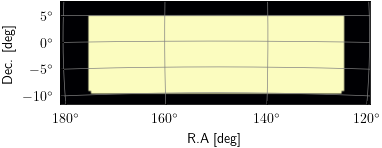

In [6]:
ps.get_enclosing_box()
plot_map(ps.W_HI,ps.wproj,have_cbar=False)
ps.box_len

In [7]:
print("total area of the survey is %.1f sqdeg" % (ps.W_HI[:,:,0].sum() * ps.pixel_area))
print("redshift range is %.1f - %.1f" % (ps.z_ch[-1], ps.z_ch[0]))

total area of the survey is 742.0 sqdeg
redshift range is 0.6 - 0.8


In [8]:
# |k| and \mu=k_para/|k|, with the 3D shape of the box
ps.kmode.shape,ps.mumode.shape, ps.k_nyquist

((27, 89, 346), (27, 89, 346), array([0.11123279, 0.114908  , 2.61111559]))

In [9]:
power_model_3d = ps.auto_power_matter_model
power_model_3d.shape

(27, 89, 346)

In [10]:
kmode = ps.kmode

kmask = kmode > 0.0
Nke = 20

kclean = kmode[kmask]
muclean = ps.mumode[kmask]

kedges = np.geomspace(
    np.min(kclean), np.max(kclean), Nke
)
Nmodes, _, _ = binned_statistic(kclean, [], "count", kedges)
Nmask = ~(Nmodes==0.0)
k = np.sqrt(kedges[1:] * kedges[:-1])[Nmask]
k

array([0.00313231, 0.00450607, 0.00648234, 0.00932536, 0.01341527,
       0.01929893, 0.02776304, 0.03993934, 0.0574559 , 0.08265486,
       0.11890556, 0.17105506, 0.24607624, 0.35400016, 0.50925725,
       0.73260687, 1.05391299, 1.51613727, 2.18108349])

In [11]:
Nmodes

array([2.00000e+00, 2.00000e+00, 1.00000e+00, 2.00000e+01, 4.30000e+01,
       1.17000e+02, 3.41000e+02, 1.00400e+03, 2.82900e+03, 8.42200e+03,
       2.07590e+04, 2.52330e+04, 3.10830e+04, 4.27220e+04, 6.02560e+04,
       8.57080e+04, 1.22705e+05, 1.76509e+05, 2.53681e+05])

## Lets try an a bit more involved PS 

In [12]:
ps.cosmo # This seems to be an astropy object

w0waCDM(name='new', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Ode0=0.6888523996875395, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897, w0=-1.0, wa=0.0)

In [13]:
print(ps.fiducial_cosmology)
print(ps.true_cosmology)

{'tau': 0.0561, 'Neff': 3.046, 'omega_cold': 0.30966, 'As': 2.105209331337507e-09, 'omega_baryon': 0.04897, 'ns': 0.9665, 'h': 0.6766, 'neutrino_mass': 0.06, 'w0': -1.0, 'wa': 0.0}
{'tau': 0.0561, 'Neff': 3.046, 'omega_cold': 0.30966, 'As': 2.105209331337507e-09, 'omega_baryon': 0.04897, 'ns': 0.9665, 'h': 0.6766, 'neutrino_mass': 0.06, 'w0': -1.0, 'wa': 0.0}


In [14]:
cosmo = Class_cosmo_model(ps.true_cosmology)

{}


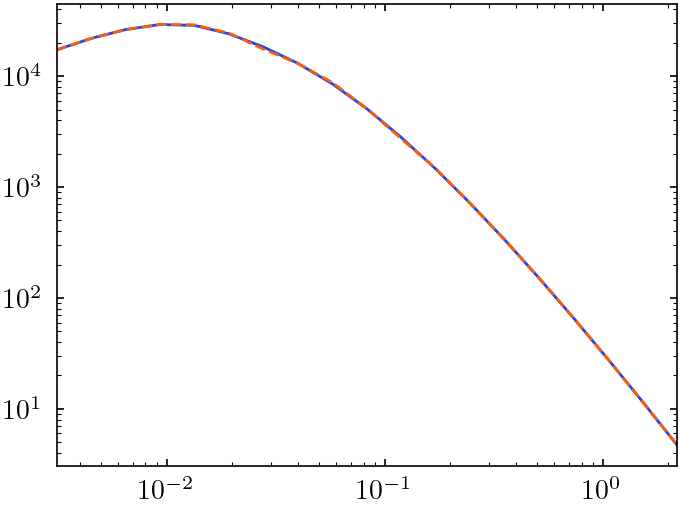

In [15]:
Pk_nw = cosmo.Pk_nw(k, 1)
plt.loglog(k, Pk_nw)
plt.loglog(k, cosmo.Pk_lin(k, 1), ls="--")

[8.63779599]


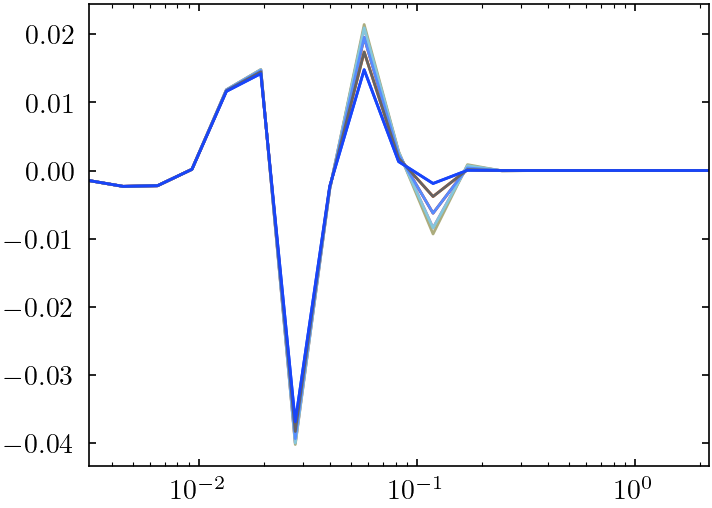

In [16]:
z = 0
mu = np.linspace(-1, 1, 9)

sigmav = cosmo.sigmav(z)
print(sigmav)

Pk_nw = cosmo.Pk_nw(k, z)
Pk_QNL = cosmo.Pk_QNL(k[:, None], mu[None, :], z, sigmav)

Pk_QNL_noBB = np.squeeze(Pk_QNL / Pk_nw[:, None, :] - 1)
plt.semilogx(k, Pk_QNL_noBB)

## $ k $ sampling avergeraging
Vectorise the functions

In [17]:
sigmav = cosmo.sigmav(ps.z)
Pqnl_samples = cosmo.Pk_QNL(ps.kmode, ps.mumode, ps.z, sigmav)

/home/sefa/Desktop/projects/meerklass/bao-systematics-task/scripts/classy_wraper_for_m21cm.py:332: RuntimeWarning: divide by zero encountered in log
  Psl_peaks = natural(np.log(k))
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/scripts/classy_wraper_for_m21cm.py:341: RuntimeWarning: divide by zero encountered in log
  Psl_valleys = natural(np.log(k))
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/scripts/classy_wraper_for_m21cm.py:84: RuntimeWarning: divide by zero encountered in log
  logPk[..., i] = natural(np.log(k))


## Testing AP

In [18]:
true_cosmology = {"h":0.71, "omega_baryon":0.05, "omega_cold":0.35}
print(*cosmo.transform_input_dict_to_class(true_cosmology))
# ps.true_cosmology = true_cosmology
# ps.alpha_parallel, ps.alpha_perp

{}
{'tau': 0.0561, 'h': 0.71, 'Neff': 3.046, 'neutrino_mass': 0.06, 'omega_cold': 0.35, 'omega_baryon': 0.05, 'w0': -1, 'wa': 0.0, 'As': 2.105209331337507e-09, 'ns': 0.9665} {'A_s': 2.105209331337507e-09, 'n_s': 0.9665, 'T_cmb': 2.7255, 'tau_reio': 0.0561, 'reio_parametrization': 'reio_camb', 'Omega_b': 0.05, 'N_ur': 2.0313333333333334, 'N_ncdm': 1, 'T_ncdm': 0.7163687246184776, 'Omega_ncdm': 0.00127916319166814, 'h': 0.71, 'Omega_cdm': 0.29872083680833184, 'Omega_Lambda': 0.0, 'w0_fld': -1, 'wa_fld': 0.0, 'Omega_k': 0.0, 'output': 'mTk, mPk', 'P_k_max_1/Mpc': 5, 'z_max_pk': 10}


In [19]:
#class instance for new fid cosmology
cosmo = Class_cosmo_model(ps.fiducial_cosmology)
# cosmo_true = Class_cosmo_model(true_cosmology)
cosmo_true = cosmo

{}


In [20]:
def alpha_parallel(true:Class_cosmo_model, fiducial:Class_cosmo_model, z):
    Hr = true.Hubble(z) * true.rsdrag
    Hr_fid = fiducial.Hubble(z) * fiducial.rsdrag
    return Hr_fid / Hr

def alpha_perp(true:Class_cosmo_model, fiducial:Class_cosmo_model, z):
    DAr = true.comoving_Distance(z) / true.rsdrag
    DAr_fid = fiducial.comoving_Distance(z) / fiducial.rsdrag
    return DAr / DAr_fid

In [21]:
alpha_parallel(cosmo_true, cosmo, ps.z), alpha_perp(cosmo_true, cosmo, ps.z)

(1.0, 1.0)

<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_8067/1412854102.py:9: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("$\chi\,[\mathrm{Mpc}]$")


Text(0, 0.5, '$\\chi\\,[\\mathrm{Mpc}]$')

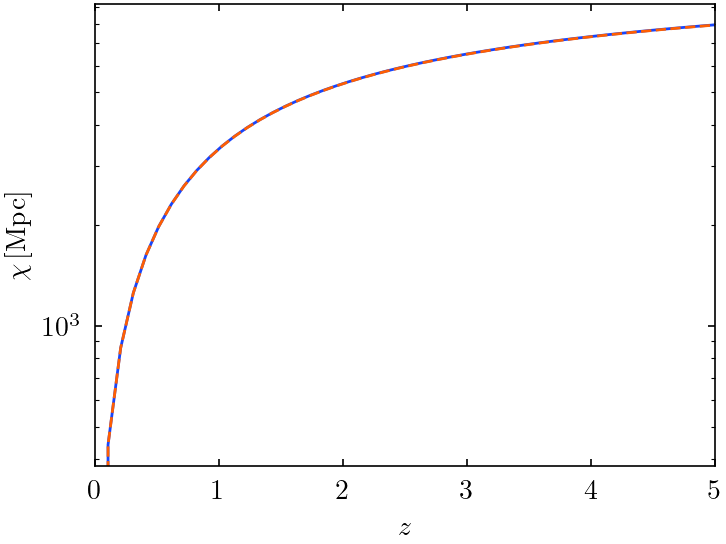

In [22]:
z = np.linspace(0, 5)
chi = cosmo_true.comoving_Distance(z) # Mpc 

chi_21cm = ps.astropy_cosmo_true.comoving_distance(z)
plt.semilogy(z, chi)
plt.semilogy(z, chi_21cm, ls="--")

plt.xlabel("$z$")
plt.ylabel("$\chi\,[\mathrm{Mpc}]$")

<>:9: SyntaxWarning: invalid escape sequence '\,'
<>:9: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_8067/3870863382.py:9: SyntaxWarning: invalid escape sequence '\,'
  plt.ylabel("$H(z)\,[\mathrm{km}\,\mathrm{s}^{-1}\,\mathrm{Mpc}^{-1}]$")


Text(0, 0.5, '$H(z)\\,[\\mathrm{km}\\,\\mathrm{s}^{-1}\\,\\mathrm{Mpc}^{-1}]$')

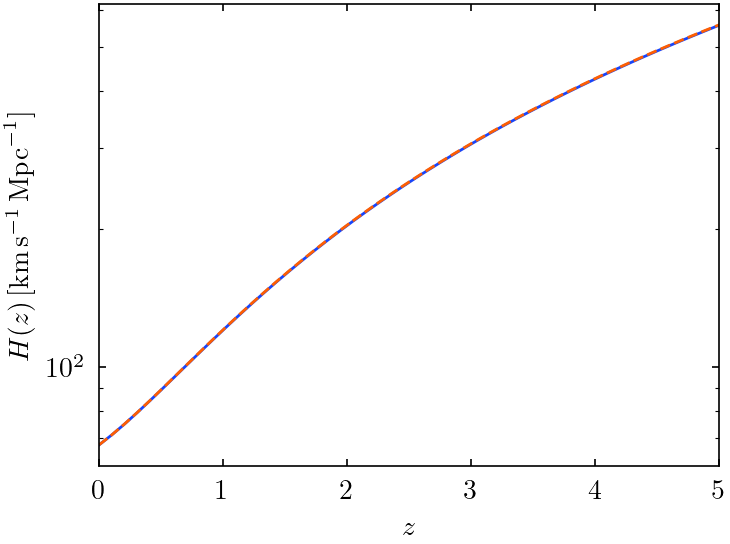

In [23]:
z = np.linspace(0, 5)
H = cosmo_true.Hubble(z) # Mpc 

H_21cm = ps.astropy_cosmo_true.H(z)
plt.semilogy(z, H * c.c / 1e3)
plt.semilogy(z, H_21cm, ls="--")

plt.xlabel("$z$")
plt.ylabel("$H(z)\,[\mathrm{km}\,\mathrm{s}^{-1}\,\mathrm{Mpc}^{-1}]$")

In [24]:
cosmo.rsdrag, ps.sound_horizon_drag_fiducial

(147.38995553084115, 147.35690949677576)

In [25]:
cosmo_true.rsdrag, ps.sound_horizon_drag_true

(147.38995553084115, 147.35690949677576)

## RSD

In [26]:
print(ps.tracer_bias_1, "hi bias")
print(ps.sigma_v_1, "FOG size")

1.5 hi bias
0.0 FOG size


In [27]:
T2 = ps.average_hi_temp**2
kaiser = (ps.tracer_bias_1 + cosmo_true.f_lin(ps.z) * muclean**2)**2

sigmaV = cosmo.sigmav(ps.z)
pqnl = cosmo.Pk_QNL(kclean, muclean, ps.z, sigmaV).squeeze(-1)
pmm = cosmo.Pk_lin(kclean, ps.z).squeeze(-1)

Ps_rsd_noobs_class = T2 * kaiser * pqnl
Ps_rsd_noqnl_noobs_class = T2 * kaiser * pmm
Ps_norsd_noobs_class = T2 * ps.tracer_bias_1**2 * pqnl
Ps_norsd_noqnl_noobs_class = T2 * ps.tracer_bias_1**2 * pmm

Do some mild averaging

In [28]:
Ps_1d_rsd_noobs_class, _, _ = binned_statistic( kclean, Ps_rsd_noobs_class, "mean", kedges)
Ps_1d_rsd_noqnl_noobs_class, _, _ = binned_statistic( kclean, Ps_rsd_noqnl_noobs_class, "mean", kedges)
Ps_1d_norsd_noobs_class, _, _ = binned_statistic( kclean, Ps_norsd_noobs_class, "mean", kedges)
Ps_1d_norsd_noqnl_noobs_class, _, _ = binned_statistic( kclean, Ps_norsd_noqnl_noobs_class, "mean", kedges)

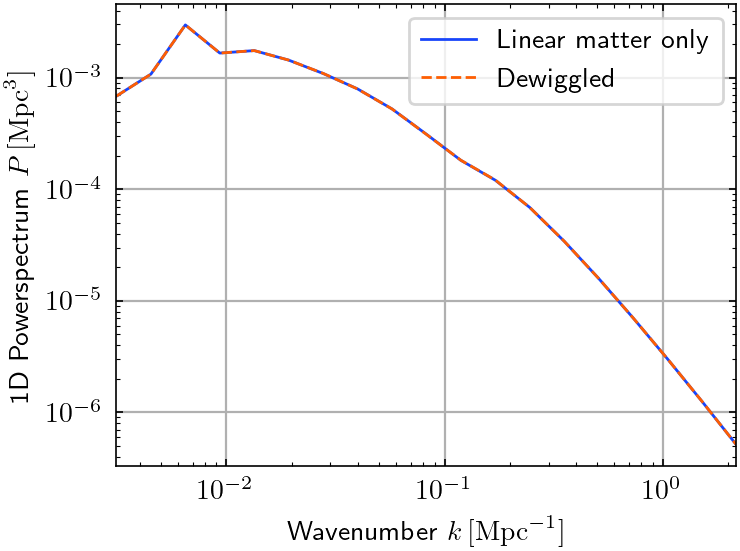

In [29]:
plt.loglog(k, Ps_1d_rsd_noqnl_noobs_class[Nmask], label="Linear matter only")
plt.loglog(k, Ps_1d_rsd_noobs_class[Nmask], ls="--", label="Dewiggled")

plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"1D Powerspectrum $P\,[\mathrm{Mpc}^{3}]$")
plt.legend()
plt.grid()

## Beam and pixelisation

In [30]:
ps.sigma_beam_ch = 0.4

beam2 = ps.beam_attenuation()[kmask]**2

In [31]:
ps.grid_scheme
ps.grid_scheme = "cic"
gridwin = ps.gridding_compensation()[kmask]**2

In [32]:
print(ps.sampling_resol)
ps.sampling_resol = [
    ps.pix_resol_in_mpc,
    ps.pix_resol_in_mpc,
    ps.los_resol_in_mpc, # Is this in fid or true
]
pixwin = ps.map_sampling()[kmask]**2 

None


In [33]:
ps.sampling_resol

[22.41160911441535, 22.41160911441535, 0.8007566089304915]

In [34]:
ps.z

0.6963003970901749

In [35]:
Ps_rsd_obs_class = Ps_rsd_noobs_class * beam2 * gridwin * pixwin
Ps_rsd_noqnl_obs_class = Ps_rsd_noqnl_noobs_class * beam2 * gridwin * pixwin

In [36]:
Ps_1d_rsd_obs_class, _, _ = binned_statistic(kclean, Ps_rsd_obs_class, "mean", kedges)
Ps_1d_rsd_noqnl_obs_class, _, _ = binned_statistic(kclean, Ps_rsd_noqnl_obs_class, "mean", kedges)

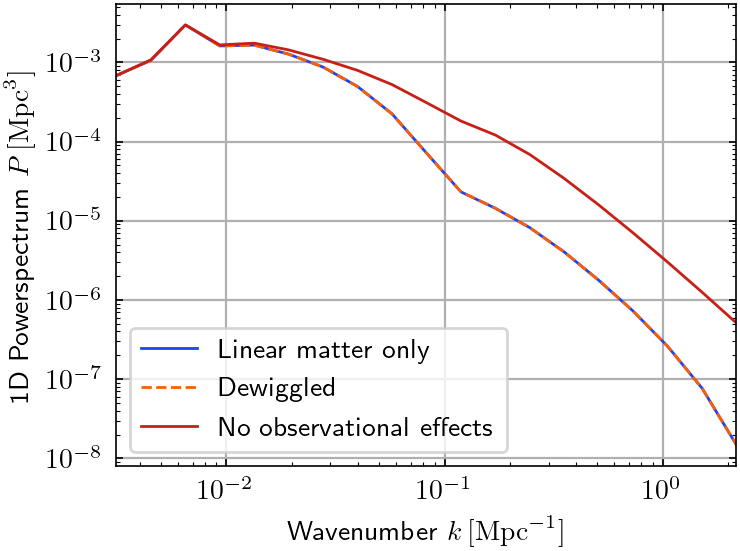

In [37]:
plt.loglog(k, Ps_1d_rsd_noqnl_obs_class[Nmask], label="Linear matter only")
plt.loglog(k, Ps_1d_rsd_obs_class[Nmask], label="Dewiggled", ls="--")
plt.loglog(k, Ps_1d_rsd_noobs_class[Nmask], label="No observational effects")

plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"1D Powerspectrum $P\,[\mathrm{Mpc}^{3}]$")
plt.legend()
plt.grid()

## Konvolution with survey weight function

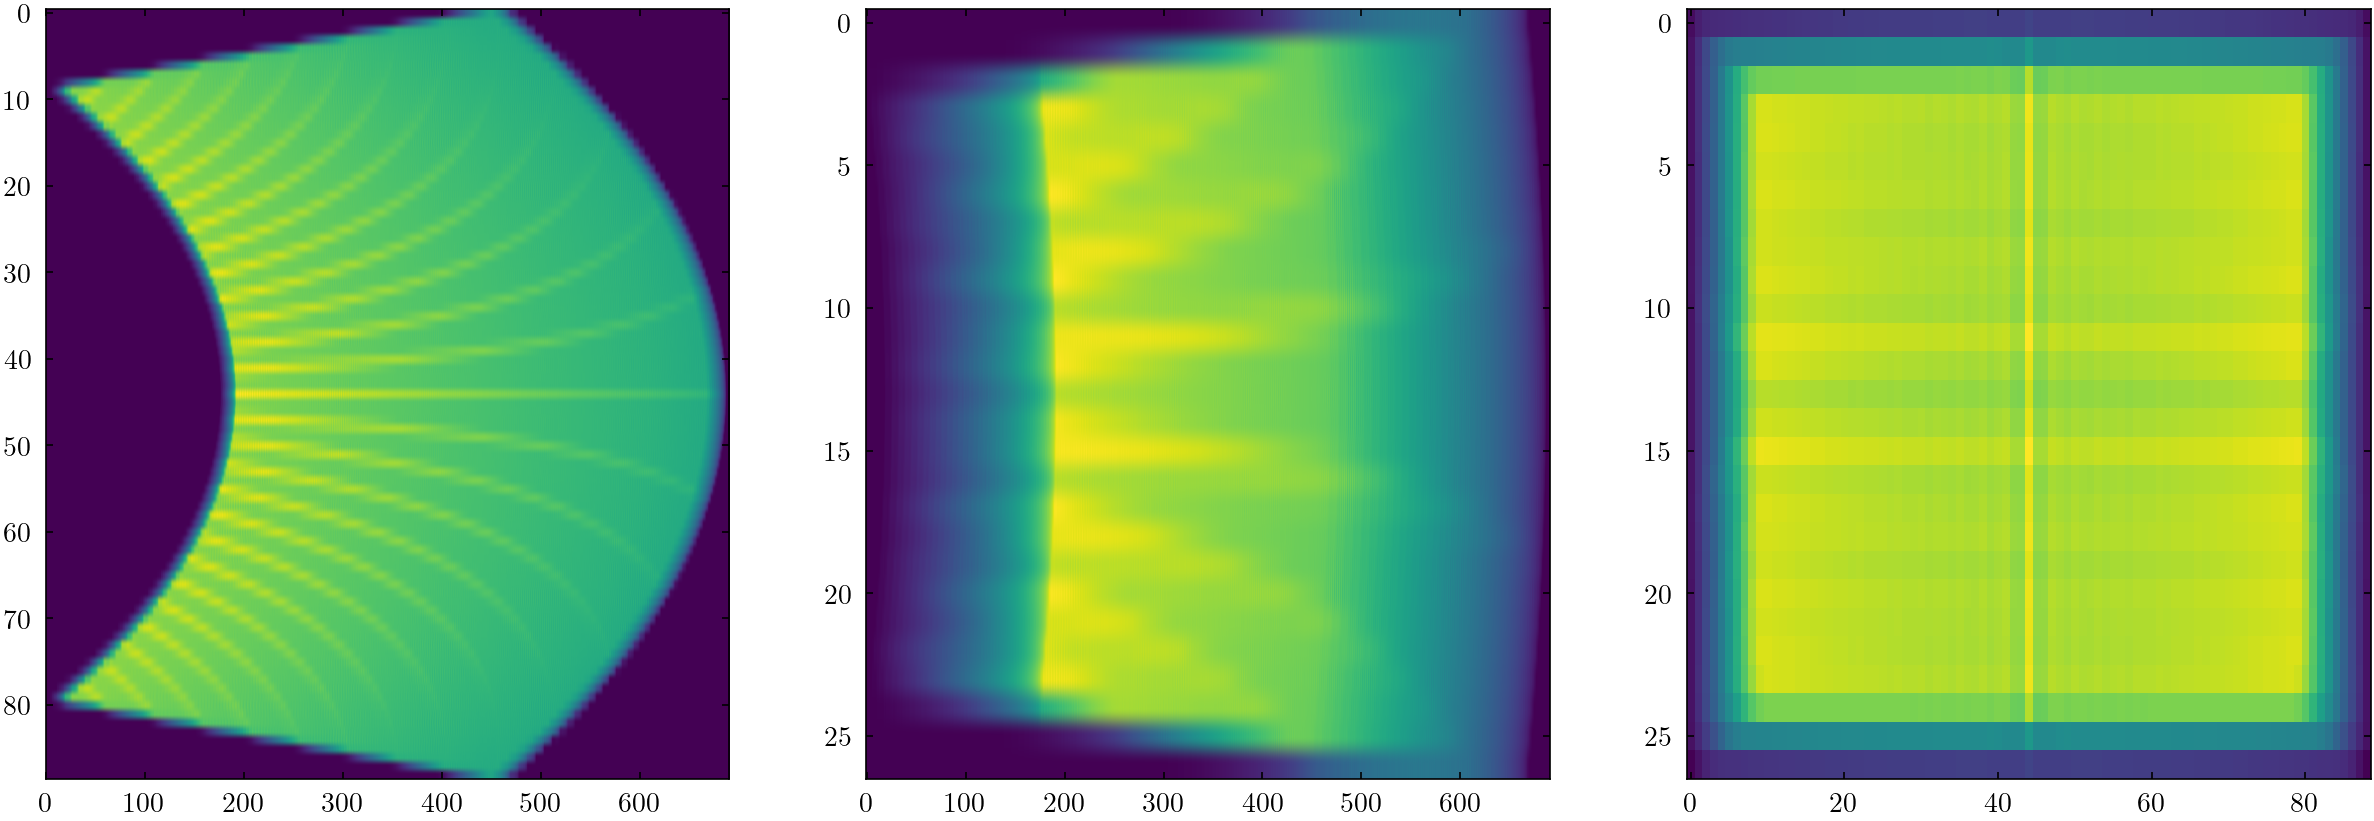

In [38]:
ps.grid_data_to_field()

fig, axes = plt.subplots(1,3,figsize=(15,5))
for i, ax in enumerate(axes):
    ax.imshow(ps.counts_in_box.mean(i),aspect='auto')

In [39]:
ps.weights_1 = ps.counts_in_box.astype('float')

In [40]:
def restore_shape(pk):
    normal = np.zeros_like(kmode)
    normal[kmask] = pk
    return normal

In [41]:
Ps_survey_model = get_modelpk_conv(
    restore_shape(Ps_rsd_obs_class),
    ps.weights_1,
    ps.weights_1,
)[kmask]

Ps_survey_model_noqnl = get_modelpk_conv(
    restore_shape(Ps_rsd_noqnl_obs_class),
    ps.weights_1,
    ps.weights_1,
)[kmask]

In [42]:
Ps_survey_model_1d, _, _ = binned_statistic(kclean, Ps_survey_model, "mean", kedges)
Ps_survey_model_1d_noqnl, _, _ = binned_statistic(kclean, Ps_survey_model_noqnl, "mean", kedges)

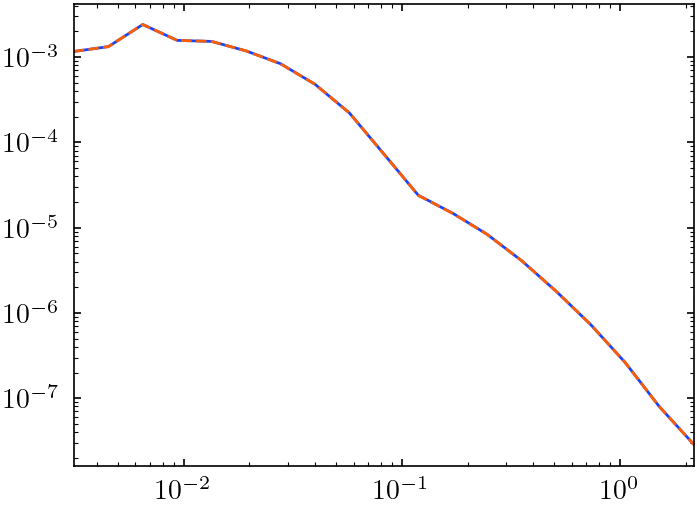

In [43]:
plt.loglog(k, Ps_survey_model_1d[Nmask])
plt.loglog(k, Ps_survey_model_1d_noqnl[Nmask], ls="--")

# Do some fake(!) "broadband extraction"

In [44]:
Pnw = cosmo.Pk_nw(kclean, ps.z).squeeze(-1)
Pnw_noobs = T2 * kaiser * Pnw

Ps_1d_nw_noobs, _, _ = binned_statistic(kclean, Pnw_noobs, "mean", kedges)
Ps_1d_nw_noobs = Ps_1d_nw_noobs[Nmask]

Pnw_obs = Pnw_noobs * beam2 * gridwin * pixwin

Pnw_obs_konv = get_modelpk_conv(
    restore_shape(Pnw_obs),
    ps.weights_1,
    ps.weights_1,
)[kmask]

Ps_1d_nw, _, _ = binned_statistic(kclean, Pnw_obs_konv, "mean", kedges)
Ps_1d_nw = Ps_1d_nw[Nmask]

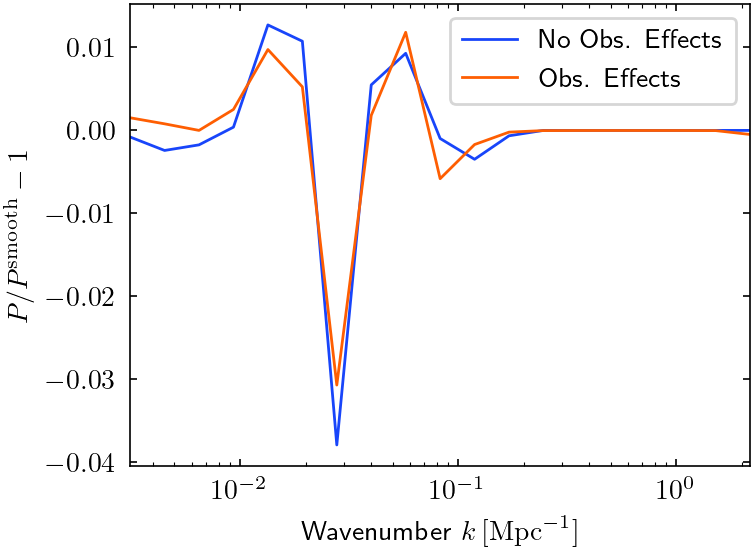

In [45]:
plt.semilogx(k, Ps_1d_rsd_noobs_class / Ps_1d_nw_noobs - 1, label="No Obs. Effects")
plt.semilogx(k, Ps_survey_model_1d / Ps_1d_nw - 1, label="Obs. Effects")

plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P / P^\mathrm{smooth} - 1$")
plt.legend()

plt.savefig("plots/wiggle_simple_model.pdf")

# Compare to meer21cm

In [46]:
ps.k1dbins = kedges

In [47]:
Pk_1d_noobs_norsd_matter_meer21cm, keff, _ = ps.get_1d_power(ps.auto_power_matter_model_r)
Pk_1d_noobs_norsd_matter_class, _, _ = binned_statistic(kclean, cosmo.Pk_lin(kclean, ps.z).squeeze(-1), "mean", kedges)

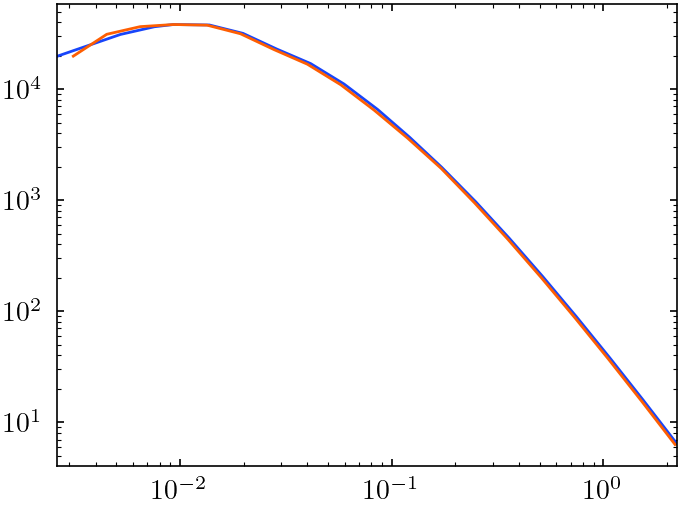

In [48]:
plt.loglog(keff, Pk_1d_noobs_norsd_matter_meer21cm)
plt.loglog(k, Pk_1d_noobs_norsd_matter_class[Nmask])

In [49]:
Pk_1d_noobs_rsd_meer21cm, keff, _ = ps.get_1d_power(
    ps.auto_power_tracer_1_model_noobs * ps.average_hi_temp**2
)

Pk_1d_noobs_rsd_class, _, _ = binned_statistic(
    kclean,
    (
        ps.average_hi_temp**2
        * (ps.tracer_bias_1 + cosmo.f_lin(ps.z) * muclean**2)**2
        * cosmo.Pk_lin(kclean, ps.z).squeeze(-1)
    ).flatten(),
    "mean",
    kedges
)

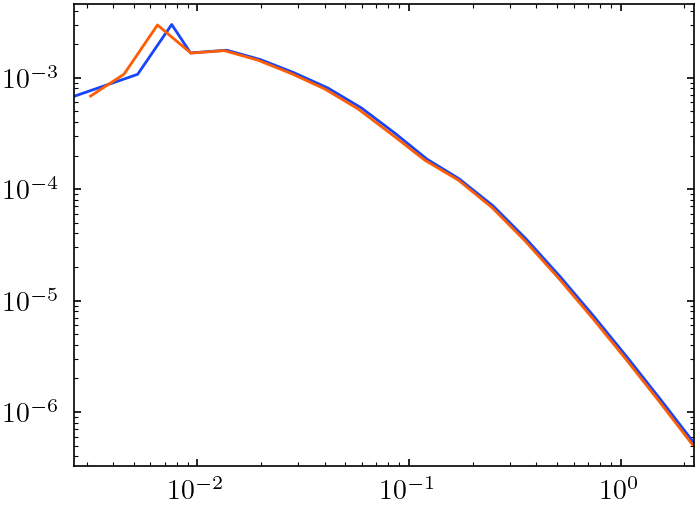

In [50]:
plt.loglog(keff, Pk_1d_noobs_rsd_meer21cm)
plt.loglog(k, Pk_1d_noobs_rsd_class[Nmask])

In [51]:
ps.include_beam = [True, False]
ps.include_sky_sampling = [True, False]
ps.compensate = [True, True]

In [52]:
Pk_meer21cm = ps.auto_power_tracer_1_model
Pk_1d_meer21cm, k21cm, _ = ps.get_1d_power(
    Pk_meer21cm
)

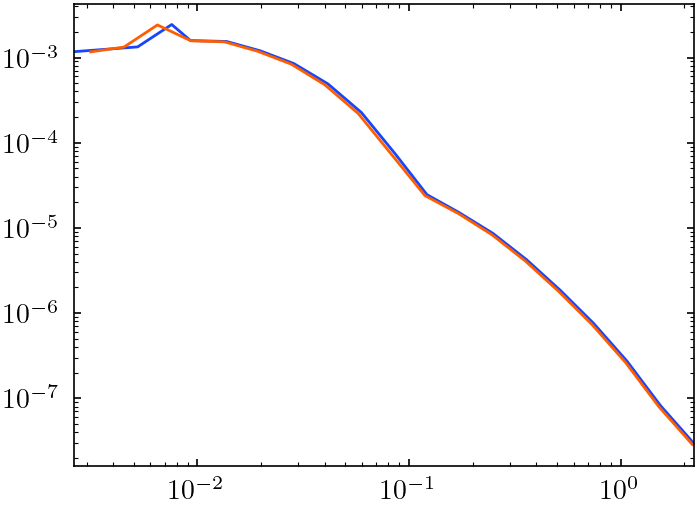

In [53]:
plt.loglog(k21cm, Pk_1d_meer21cm)
plt.loglog(k, Ps_survey_model_1d[Nmask])

# Looks fine